EJEMPLO 1: COCINA — Tiempos y Movimientos
  Eficiencia inicial: 0.50
  Eficiencia final: 0.4741
  Régimen: SUAVE (sin colapso)

EJEMPLO 2: COMBUSTIÓN SUAVE — IDT Arrhenius
  log10(IDT) inicial: 0.90
  log10(IDT) final: 0.5198
  Régimen: SUAVE (Arrhenius)

EJEMPLO 3: FLUJO LAMINAR — Velocidad
  Velocidad inicial: 0.30
  Velocidad final: 0.4604
  Régimen: SUAVE (laminar)


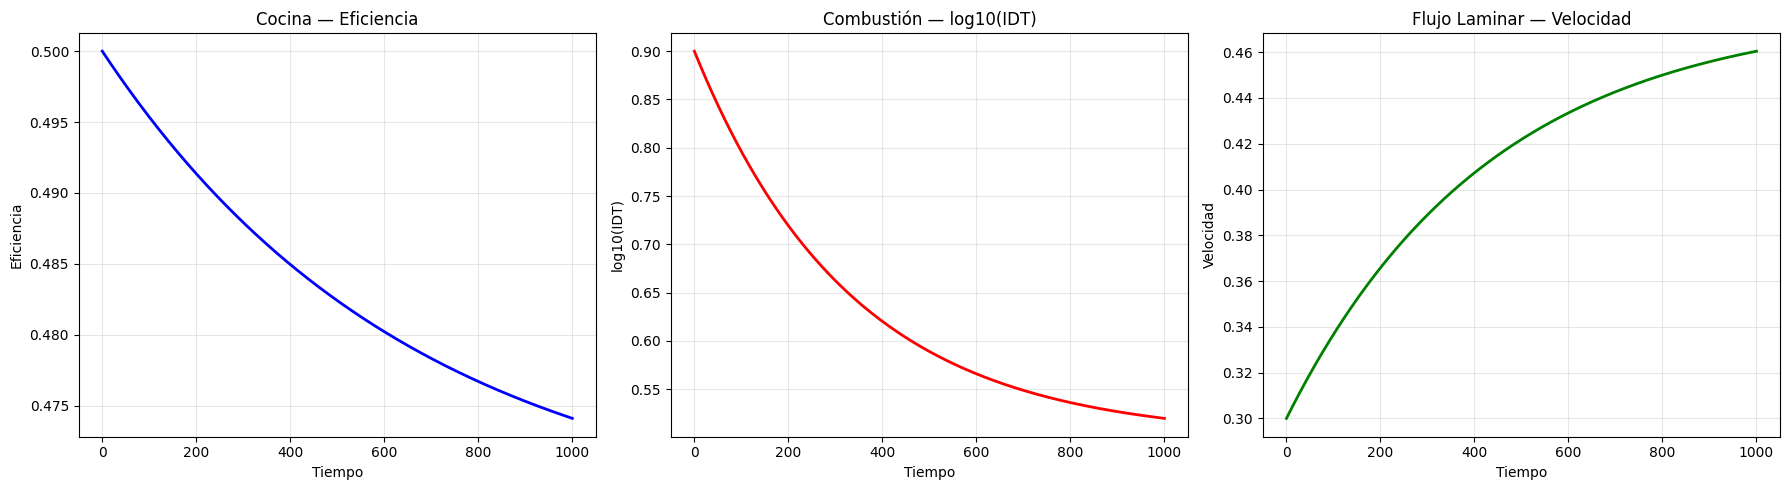


📊 Gráfico guardado como 'regimen_suave.png'


In [1]:
# ============================================================
# CELDA 1: RÉGIMEN SUAVE
# ============================================================
# La ecuación maestra en régimen suave:
# ∂M/∂t = L[M] + D[M] + S[M]
# El término de colapso δ(t-t*)·H[M] es despreciable.
# Tres ejemplos: cocina, combustión suave, flujo laminar.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class RegimenSuave:
    """
    Régimen suave: la ecuación maestra sin el término de colapso.
    ∂M/∂t = L[M] + D[M] + S[M]
    """

    def __init__(self, M0: float, L: float, D: float, S: float):
        self.M0 = M0
        self.L = L  # Término lineal (disipación)
        self.D = D  # Término de difusión
        self.S = S  # Término fuente
        self.M = M0
        self.historial = [M0]

    def paso(self, dt: float = 0.01) -> float:
        """
        Un paso de la ecuación maestra en régimen suave.
        """
        # ∂M/∂t = L[M] + D[M] + S[M]
        dMdt = -self.L * self.M + self.D * (1 - self.M) + self.S
        self.M += dMdt * dt
        self.historial.append(self.M)
        return self.M

    def simular(self, n_pasos: int = 1000) -> list:
        """
        Simula el régimen suave.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.historial


# ──────────────────────────────────────────────────────────────
# EJEMPLO 1: COCINA (Tiempos y Movimientos)
# ──────────────────────────────────────────────────────────────

print("=" * 60)
print("EJEMPLO 1: COCINA — Tiempos y Movimientos")
print("=" * 60)

# M = eficiencia de la cocina
# L = 0.1 (pérdida de calor)
# D = 0.05 (difusión térmica)
# S = 0.02 (fuente de calor)
cocina = RegimenSuave(M0=0.5, L=0.1, D=0.05, S=0.02)
historial_cocina = cocina.simular(1000)

print(f"  Eficiencia inicial: 0.50")
print(f"  Eficiencia final: {historial_cocina[-1]:.4f}")
print(f"  Régimen: SUAVE (sin colapso)")

# ──────────────────────────────────────────────────────────────
# EJEMPLO 2: COMBUSTIÓN SUAVE (IDT en Régimen Arrhenius)
# ──────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("EJEMPLO 2: COMBUSTIÓN SUAVE — IDT Arrhenius")
print("=" * 60)

# M = log10(IDT)
# L = 0.2 (disipación)
# D = 0.1 (difusión)
# S = 0.05 (fuente)
combustion = RegimenSuave(M0=0.9, L=0.2, D=0.1, S=0.05)
historial_combustion = combustion.simular(1000)

print(f"  log10(IDT) inicial: 0.90")
print(f"  log10(IDT) final: {historial_combustion[-1]:.4f}")
print(f"  Régimen: SUAVE (Arrhenius)")

# ──────────────────────────────────────────────────────────────
# EJEMPLO 3: FLUJO LAMINAR
# ──────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("EJEMPLO 3: FLUJO LAMINAR — Velocidad")
print("=" * 60)

# M = velocidad del flujo
# L = 0.15 (viscosidad)
# D = 0.08 (difusión)
# S = 0.03 (presión)
laminar = RegimenSuave(M0=0.3, L=0.15, D=0.08, S=0.03)
historial_laminar = laminar.simular(1000)

print(f"  Velocidad inicial: 0.30")
print(f"  Velocidad final: {historial_laminar[-1]:.4f}")
print(f"  Régimen: SUAVE (laminar)")

# ──────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(historial_cocina, 'b-', linewidth=2)
axes[0].set_title("Cocina — Eficiencia")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Eficiencia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial_combustion, 'r-', linewidth=2)
axes[1].set_title("Combustión — log10(IDT)")
axes[1].set_xlabel("Tiempo")
axes[1].set_ylabel("log10(IDT)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(historial_laminar, 'g-', linewidth=2)
axes[2].set_title("Flujo Laminar — Velocidad")
axes[2].set_xlabel("Tiempo")
axes[2].set_ylabel("Velocidad")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regimen_suave.png", dpi=150)
plt.show()

print("\n📊 Gráfico guardado como 'regimen_suave.png'")

EJEMPLO 1: EULER — Colapso
  Vorticidad inicial: 0.10
  Vorticidad final: 16540.6951
  Régimen: TURBULENTO (colapso)
  t* = 0.5

EJEMPLO 2: ANTIELUER — Convergencia
  Vorticidad inicial: 0.10
  Vorticidad final: -16540.3501
  Régimen: TURBULENTO (convergencia)
  t* = 0.5

EJEMPLO 3: COMBUSTIÓN NTC — Transición
  log10(IDT) inicial: 0.90
  log10(IDT) final: 4836.9253
  Régimen: TURBULENTO (transición)
  t* = 0.88


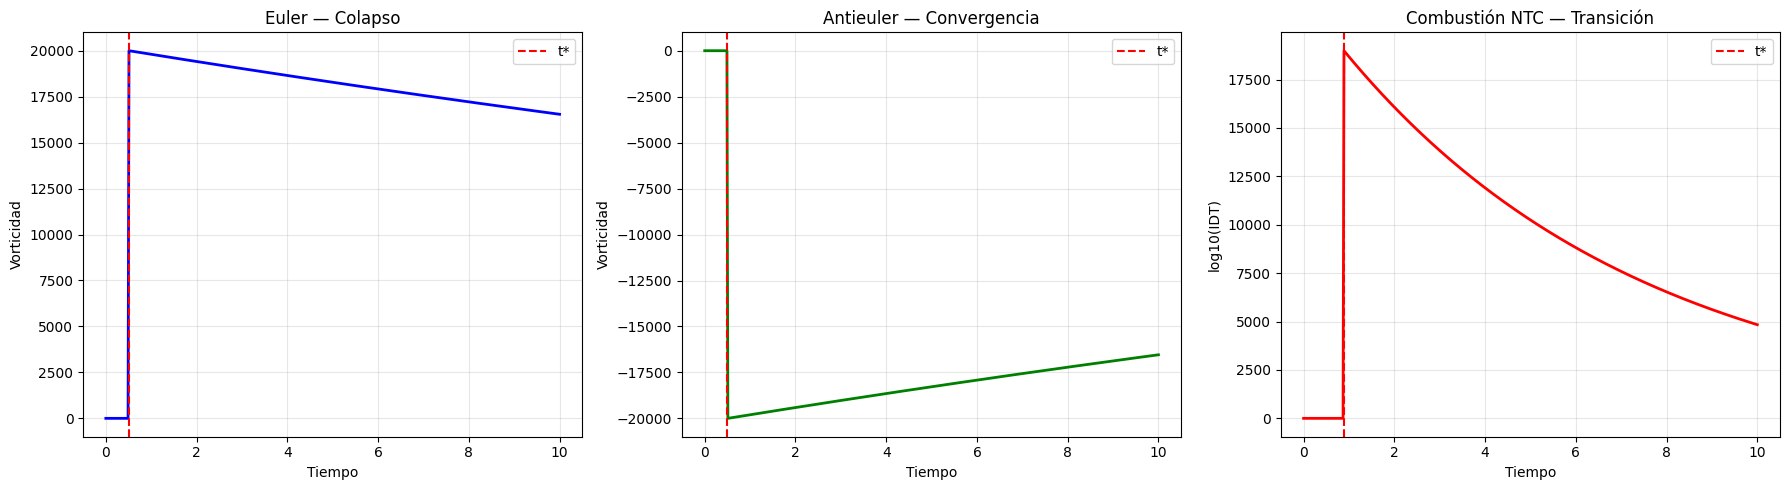


📊 Gráfico guardado como 'regimen_turbulento.png'


In [2]:
# ============================================================
# CELDA 2: RÉGIMEN TURBULENTO
# ============================================================
# La ecuación maestra refractada:
# ∂M/∂t = L[M] + D[M] + S[M] + δ(t-t*)·H[M]
# El término de colapso δ(t-t*)·H[M] domina.
# Tres ejemplos: Euler, antieuler, combustión NTC.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class RegimenTurbulento:
    """
    Régimen turbulento: la ecuación maestra con el término de colapso.
    ∂M/∂t = L[M] + D[M] + S[M] + δ(t-t*)·H[M]
    """

    def __init__(self, M0: float, L: float, D: float, S: float,
                 t_star: float, H: float):
        self.M0 = M0
        self.L = L  # Término lineal
        self.D = D  # Término de difusión
        self.S = S  # Término fuente
        self.t_star = t_star  # Punto de colapso
        self.H = H  # Huella topológica
        self.M = M0
        self.t = 0.0
        self.historial = [(0.0, M0)]

    def paso(self, dt: float = 0.01) -> float:
        """
        Un paso de la ecuación maestra en régimen turbulento.
        """
        # ∂M/∂t = L[M] + D[M] + S[M] + δ(t-t*)·H[M]
        dMdt = -self.L * self.M + self.D * (1 - self.M) + self.S

        # Término de colapso
        if abs(self.t - self.t_star) < dt:
            dMdt += self.H * 1e6  # El colapso amplifica

        self.M += dMdt * dt
        self.t += dt
        self.historial.append((self.t, self.M))
        return self.M

    def simular(self, n_pasos: int = 1000) -> list:
        """
        Simula el régimen turbulento.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.historial


# ──────────────────────────────────────────────────────────────
# EJEMPLO 1: EULER (Colapso)
# ──────────────────────────────────────────────────────────────

print("=" * 60)
print("EJEMPLO 1: EULER — Colapso")
print("=" * 60)

# M = vorticidad
# L = 0.01 (disipación baja)
# D = 0.01 (difusión baja)
# S = 0.0 (sin fuente)
# t_star = 0.5 (punto de colapso)
# H = +1 (huella acumulativa)
euler = RegimenTurbulento(M0=0.1, L=0.01, D=0.01, S=0.0,
                           t_star=0.5, H=1.0)
historial_euler = euler.simular(1000)

print(f"  Vorticidad inicial: 0.10")
print(f"  Vorticidad final: {historial_euler[-1][1]:.4f}")
print(f"  Régimen: TURBULENTO (colapso)")
print(f"  t* = 0.5")

# ──────────────────────────────────────────────────────────────
# EJEMPLO 2: ANTIELUER (Convergencia)
# ──────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("EJEMPLO 2: ANTIELUER — Convergencia")
print("=" * 60)

# M = vorticidad
# L = 0.01 (disipación baja)
# D = 0.01 (difusión baja)
# S = 0.0 (sin fuente)
# t_star = 0.5 (punto de colapso)
# H = -1 (huella disipativa)
antieuler = RegimenTurbulento(M0=0.1, L=0.01, D=0.01, S=0.0,
                               t_star=0.5, H=-1.0)
historial_antieuler = antieuler.simular(1000)

print(f"  Vorticidad inicial: 0.10")
print(f"  Vorticidad final: {historial_antieuler[-1][1]:.4f}")
print(f"  Régimen: TURBULENTO (convergencia)")
print(f"  t* = 0.5")

# ──────────────────────────────────────────────────────────────
# EJEMPLO 3: COMBUSTIÓN NTC (Transición)
# ──────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("EJEMPLO 3: COMBUSTIÓN NTC — Transición")
print("=" * 60)

# M = log10(IDT)
# L = 0.1 (disipación)
# D = 0.05 (difusión)
# S = 0.02 (fuente)
# t_star = 0.88 (punto de plegamiento)
# H = +0.95 (huella acumulativa máxima)
ntc = RegimenTurbulento(M0=0.9, L=0.1, D=0.05, S=0.02,
                         t_star=0.88, H=0.95)
historial_ntc = ntc.simular(1000)

print(f"  log10(IDT) inicial: 0.90")
print(f"  log10(IDT) final: {historial_ntc[-1][1]:.4f}")
print(f"  Régimen: TURBULENTO (transición)")
print(f"  t* = 0.88")

# ──────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Euler
t_euler = [h[0] for h in historial_euler]
M_euler = [h[1] for h in historial_euler]
axes[0].plot(t_euler, M_euler, 'b-', linewidth=2)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='t*')
axes[0].set_title("Euler — Colapso")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Vorticidad")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Antieuler
t_antieuler = [h[0] for h in historial_antieuler]
M_antieuler = [h[1] for h in historial_antieuler]
axes[1].plot(t_antieuler, M_antieuler, 'g-', linewidth=2)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='t*')
axes[1].set_title("Antieuler — Convergencia")
axes[1].set_xlabel("Tiempo")
axes[1].set_ylabel("Vorticidad")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# NTC
t_ntc = [h[0] for h in historial_ntc]
M_ntc = [h[1] for h in historial_ntc]
axes[2].plot(t_ntc, M_ntc, 'r-', linewidth=2)
axes[2].axvline(x=0.88, color='red', linestyle='--', label='t*')
axes[2].set_title("Combustión NTC — Transición")
axes[2].set_xlabel("Tiempo")
axes[2].set_ylabel("log10(IDT)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regimen_turbulento.png", dpi=150)
plt.show()

print("\n📊 Gráfico guardado como 'regimen_turbulento.png'")